In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# load processed data
df = pd.read_csv('../data/processed/processed_data.csv')

print("Data loaded successfully")
print("Shape:", df.shape)
print("Fraud cases:", df['Class'].sum())

Data loaded successfully
Shape: (284807, 32)
Fraud cases: 492


In [6]:
# separate features and target

X=df.drop("Class",axis=1)
y=df["Class"]


# train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# apply SMOTE only on training data
smote=SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train shape_after_smote:", X_train_smote.shape)

print("\nBefore SMOTE:")
print("Fraud:", y_train.sum())
print("Legit:", (y_train==0).sum())

print("\nAfter SMOTE:")
print("Fraud:", y_train_smote.sum())
print("Legit:", (y_train_smote==0).sum())


X_train shape: (227845, 31)
X_test shape: (56962, 31)
X_train shape_after_smote: (454902, 31)

Before SMOTE:
Fraud: 394
Legit: 227451

After SMOTE:
Fraud: 227451
Legit: 227451


In [8]:
# train logistic regression without SMOTE first
# this is our baseline model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# predict on test data
lr_pred = lr_model.predict(X_test)

# evaluate
print("Logistic Regression WITHOUT SMOTE")
print("F1 Score:", round(f1_score(y_test, lr_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression WITHOUT SMOTE
F1 Score: 0.7168
ROC-AUC: 0.8162

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



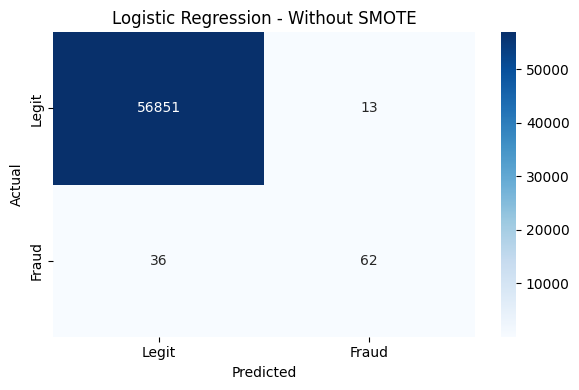

True Negatives  (Legit correctly caught): 56851
False Positives (Legit wrongly flagged): 13
False Negatives (Fraud missed): 36
True Positives  (Fraud correctly caught): 62


In [10]:
# confusion matrix shows exactly what model got right and wrong
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Logistic Regression - Without SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# print the numbers clearly
print("True Negatives  (Legit correctly caught):", cm[0][0])
print("False Positives (Legit wrongly flagged):", cm[0][1])
print("False Negatives (Fraud missed):", cm[1][0])
print("True Positives  (Fraud correctly caught):", cm[1][1])

In [11]:
# train random forest without SMOTE
# compare with logistic regression
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# predict on test data
rf_pred = rf_model.predict(X_test)

# evaluate
print("=== Random Forest WITHOUT SMOTE ===")
print("F1 Score:", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest WITHOUT SMOTE ===
F1 Score: 0.8681
ROC-AUC: 0.903

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
# train xgboost without SMOTE
# scale_pos_weight handles imbalance automatically
# it tells model to pay more attention to fraud cases

fraud_count = (y_train == 1).sum()
legit_count = (y_train == 0).sum()
scale = legit_count / fraud_count

print("scale_pos_weight value:", round(scale, 2))

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# predict on test data
xgb_pred = xgb_model.predict(X_test)

# evaluate
print("\n=== XGBoost WITHOUT SMOTE ===")
print("F1 Score:", round(f1_score(y_test, xgb_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

scale_pos_weight value: 577.29

=== XGBoost WITHOUT SMOTE ===
F1 Score: 0.8601
ROC-AUC: 0.9234

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



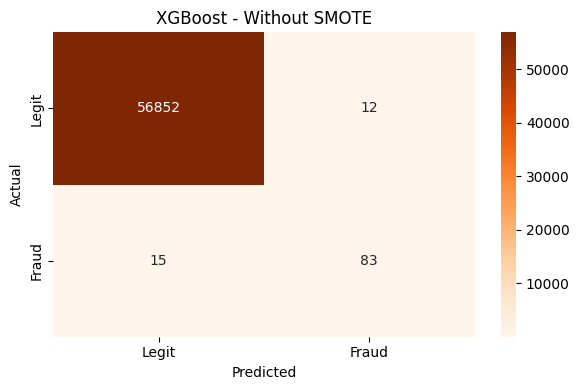

In [13]:
# confusion matrix
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('XGBoost - Without SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# now train xgboost on SMOTE balanced data
# no need for scale_pos_weight anymore
# because SMOTE already balanced the classes

xgb_smote_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb_smote_model.fit(X_train_smote, y_train_smote)

# predict on test data
# important — we still test on original test data not SMOTE data
xgb_smote_pred = xgb_smote_model.predict(X_test)

 XGBoost WITH SMOTE 
F1 Score: 0.7778
ROC-AUC: 0.9283

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.86      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



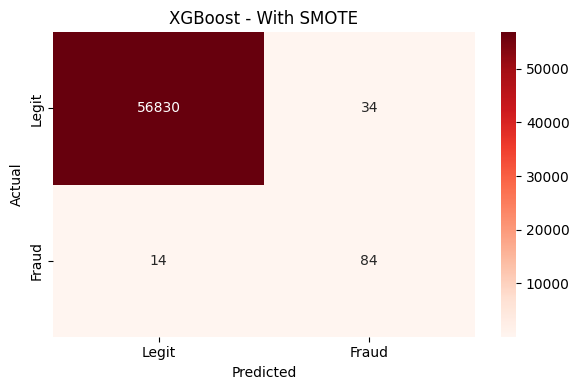

In [16]:
# evaluate
print(" XGBoost WITH SMOTE ")
print("F1 Score:", round(f1_score(y_test, xgb_smote_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_smote_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, xgb_smote_pred))


# confusion matrix
cm = confusion_matrix(y_test, xgb_smote_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('XGBoost - With SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/xgb_smote_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.model_selection import RandomizedSearchCV

# define parameters to try
params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.1, 0.3],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# create base model
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# randomized search
# n_iter=20 means try 20 random combinations
# cv=3 means 3 fold cross validation
# scoring='f1' means optimize for F1 score
# n_jobs=-1 means use all CPU cores

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=params,
    n_iter=20,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# fit on SMOTE data
random_search.fit(X_train_smote, y_train_smote)

print("Best parameters found:")
print(random_search.best_params_)
print("\nBest recall Score during tuning:", round(random_search.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 0.8}

Best F1 Score during tuning: 1.0


=== Final Tuned XGBoost WITH SMOTE ===
F1 Score: 0.806
ROC-AUC: 0.9131

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.83      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962



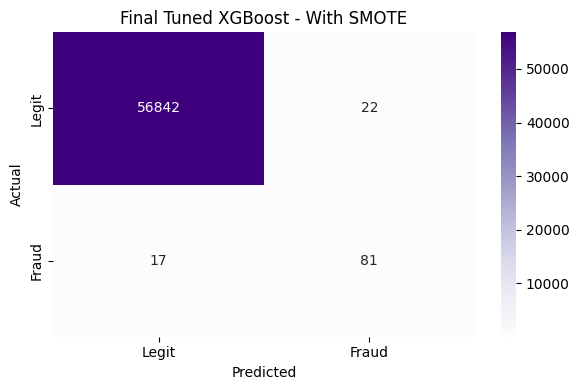

In [20]:
# train final model with best parameters found
final_model = XGBClassifier(
    subsample=1.0,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.3,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# train on SMOTE data
final_model.fit(X_train_smote, y_train_smote)

# predict on test data
final_pred = final_model.predict(X_test)

# evaluate
print("=== Final Tuned XGBoost WITH SMOTE ===")
print("F1 Score:", round(f1_score(y_test, final_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, final_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, final_pred))

# confusion matrix
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Final Tuned XGBoost - With SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/final_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import pickle
import os

# create model folder if not exists
os.makedirs('../model', exist_ok=True)

# save the model
with open('../model/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_smote_model, f)

print("Model saved successfully!")
print("Location: model/xgb_model.pkl")

Model saved successfully!
Location: model/xgb_model.pkl
